<a href="https://colab.research.google.com/github/amoahgrace/Grace-Amoah-Com-763-S25016912-/blob/main/Grace_Amoah_S25016912_Com_763.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv('job_salary_prediction_dataset.csv').sample(n=10000,
                                                              random_state=42)

# Display the first few rows to verify loading
print(df.head())

                 job_title  experience_years education_level  skills_count  \
38683          AI Engineer                11        Bachelor             7   
64939      DevOps Engineer                 7          Master            14   
3954    Frontend Developer                10        Bachelor             2   
120374         AI Engineer                 8        Bachelor             9   
172861   Software Engineer                 2         Diploma            12   

          industry company_size   location remote_work  certifications  salary  
38683      Telecom      Startup     Canada      Hybrid               3  164009  
64939   Healthcare        Small      India      Hybrid               1   79594  
3954        Retail      Startup      India         Yes               5   74090  
120374  Healthcare       Medium    Germany          No               4  177193  
172861      Retail        Large  Singapore      Hybrid               4  120012  


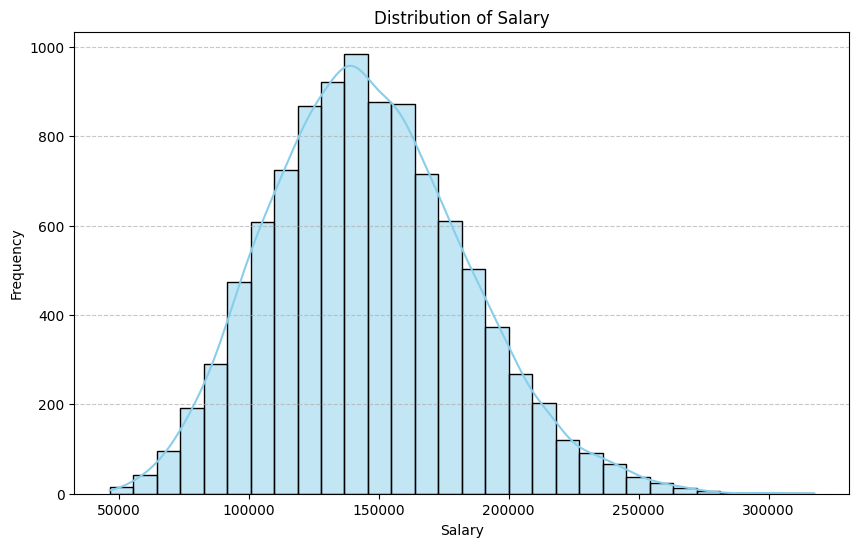

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Distribution of Salary
plt.figure(figsize=(10, 6))
sns.histplot(df['salary'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Salary')
plt.xlabel('Salary')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig('salary_distribution.png')
plt.show()

/tmp/ipykernel_2264/808705807.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='education_level', y='salary', data=df, palette='viridis')


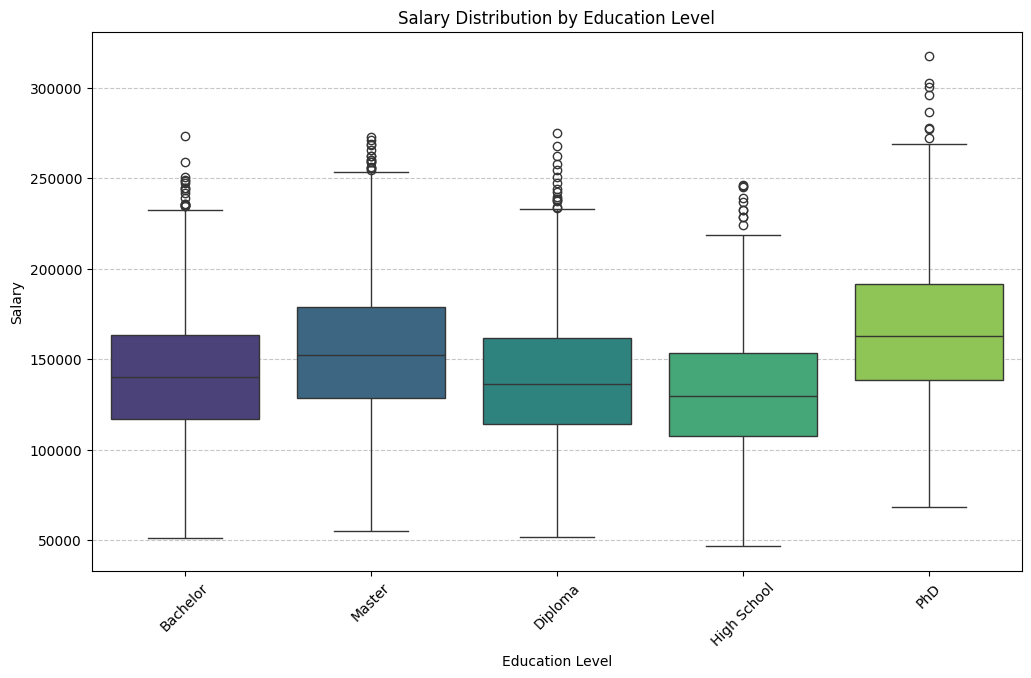

In [15]:
# 2. Salary vs. Education Level
plt.figure(figsize=(12, 7))
sns.boxplot(x='education_level', y='salary', data=df, palette='viridis')
plt.title('Salary Distribution by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Salary')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig('salary_by_education.png')
plt.show()

/tmp/ipykernel_2264/715491905.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='job_title', y='salary', data=df_top_jobs, palette='magma', order=top_job_titles)


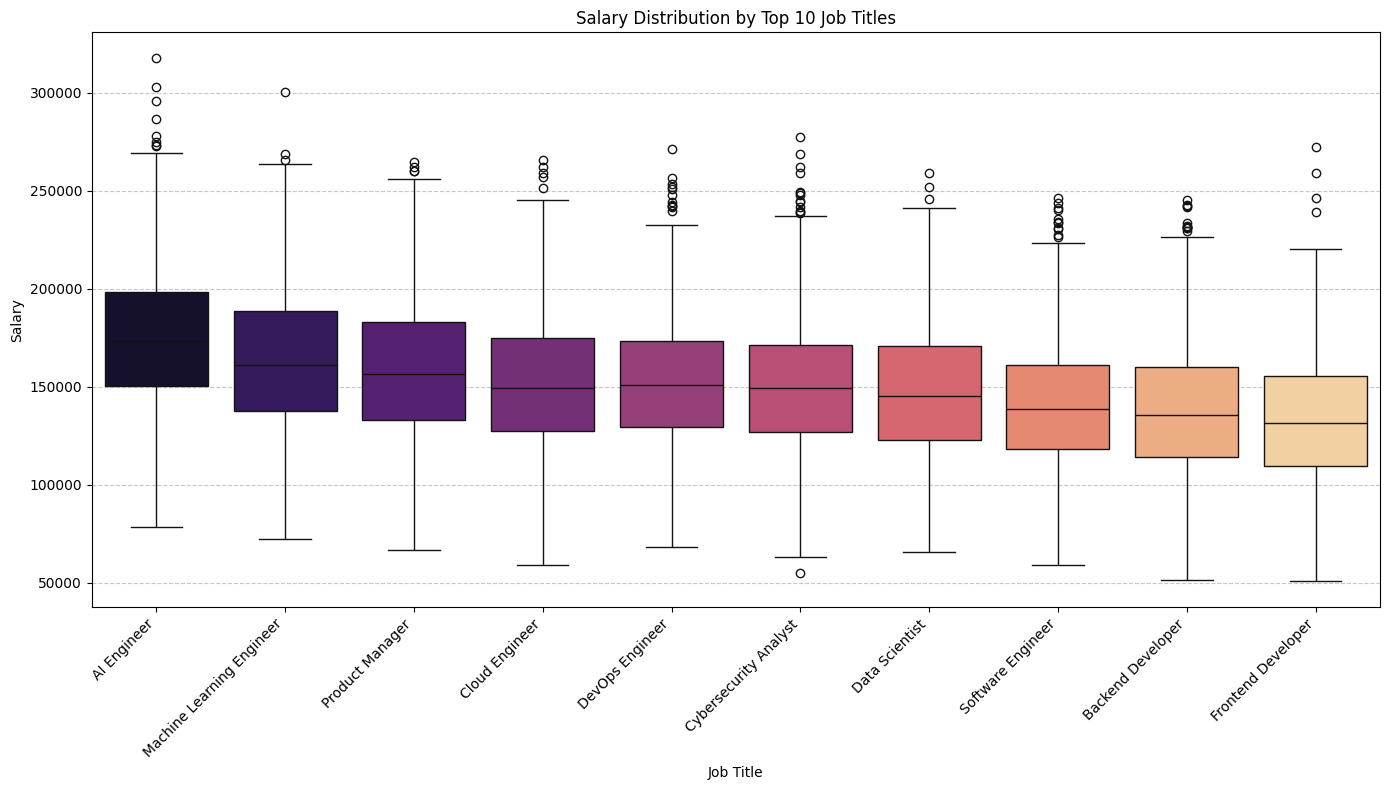

In [16]:
# 3. Salary vs. Job Title (Top 10 job titles by average salary)
top_job_titles = df.groupby('job_title')['salary'].mean().nlargest(10).index
df_top_jobs = df[df['job_title'].isin(top_job_titles)]

plt.figure(figsize=(14, 8))
sns.boxplot(x='job_title', y='salary', data=df_top_jobs, palette='magma', order=top_job_titles)
plt.title('Salary Distribution by Top 10 Job Titles')
plt.xlabel('Job Title')
plt.ylabel('Salary')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('salary_by_job_title.png')
plt.show()

       experience_years  skills_count  certifications         salary
count       10000.00000  10000.000000    10000.000000   10000.000000
mean           10.16070     10.016100        2.465600  146159.046300
std             6.09334      5.490306        1.686328   37657.238237
min             0.00000      1.000000        0.000000   46585.000000
25%             5.00000      5.000000        1.000000  119477.750000
50%            10.00000     10.000000        2.000000  143802.500000
75%            16.00000     15.000000        4.000000  170551.500000
max            20.00000     19.000000        5.000000  317497.000000


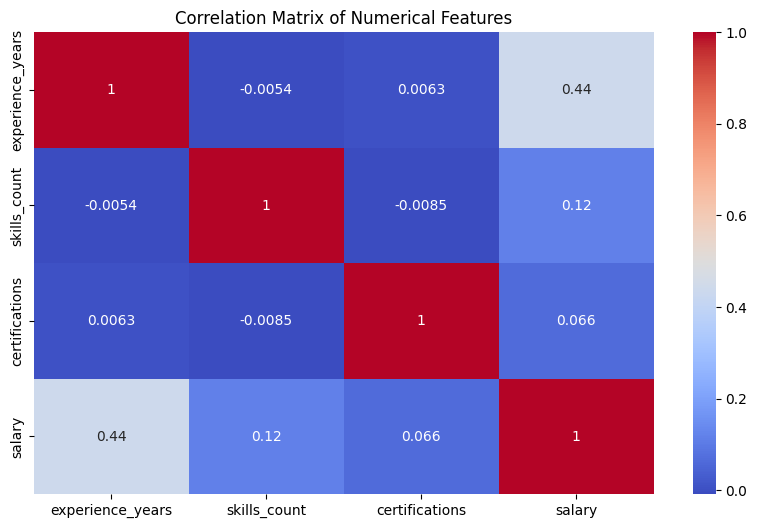

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Summary statistics
print(df.describe())

# Check for correlations between numerical features and Salary
# (Include this plot in your report)
plt.figure(figsize=(10,6))
sns.heatmap(df[['experience_years', 'skills_count', 'certifications', 'salary']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix of Numerical Features")
plt.savefig('correlation_matrix.png') # Save the plot
plt.show()

In [8]:
# Check for missing values
print(df.isnull().sum())

# Drop rows with missing values
df = df.dropna()

# Remove outliers: Keep salaries within a realistic range (e.g., $10k to $500k)
df = df[(df['salary'] >= 10000) & (df['salary'] <= 500000)]

job_title           0
experience_years    0
education_level     0
skills_count        0
industry            0
company_size        0
location            0
remote_work         0
certifications      0
salary              0
dtype: int64


In [9]:
# 1. Select Numerical Features
numerical_features = ['experience_years', 'skills_count', 'certifications']

# 2. Select Categorical Features to be encoded
categorical_features = ['job_title', 'education_level', 'industry', 'location', 'remote_work']

# 3. Create dummy variables for categorical data
df_encoded = pd.get_dummies(df[categorical_features], drop_first=True)

# 4. Combine Numerical + Encoded Categorical + Target (Salary)
X = pd.concat([df[numerical_features], df_encoded], axis=1)
y = df['salary']

print("Features being used for training:", X.columns.tolist())

Features being used for training: ['experience_years', 'skills_count', 'certifications', 'job_title_Backend Developer', 'job_title_Business Analyst', 'job_title_Cloud Engineer', 'job_title_Cybersecurity Analyst', 'job_title_Data Analyst', 'job_title_Data Scientist', 'job_title_DevOps Engineer', 'job_title_Frontend Developer', 'job_title_Machine Learning Engineer', 'job_title_Product Manager', 'job_title_Software Engineer', 'education_level_Diploma', 'education_level_High School', 'education_level_Master', 'education_level_PhD', 'industry_Education', 'industry_Finance', 'industry_Government', 'industry_Healthcare', 'industry_Manufacturing', 'industry_Media', 'industry_Retail', 'industry_Technology', 'industry_Telecom', 'location_Canada', 'location_Germany', 'location_India', 'location_Netherlands', 'location_Remote', 'location_Singapore', 'location_Sweden', 'location_UK', 'location_USA', 'remote_work_No', 'remote_work_Yes']


In [10]:
from sklearn.model_selection import train_test_split

# 80% Training, 20% Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# --- Model 1: Linear Regression ---
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

# --- Model 2: Random Forest (Usually better for salary data) ---
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

# --- EVALUATION (Compare these in your report) ---
print(f"Linear Regression R2 Score: {r2_score(y_test, lr_preds):.2f}")
print(f"Random Forest R2 Score: {r2_score(y_test, rf_preds):.2f}")
print(f"Random Forest MAE: ${mean_absolute_error(y_test, rf_preds):.2f}")

Linear Regression R2 Score: 0.80
Random Forest R2 Score: 0.74
Random Forest MAE: $15743.67


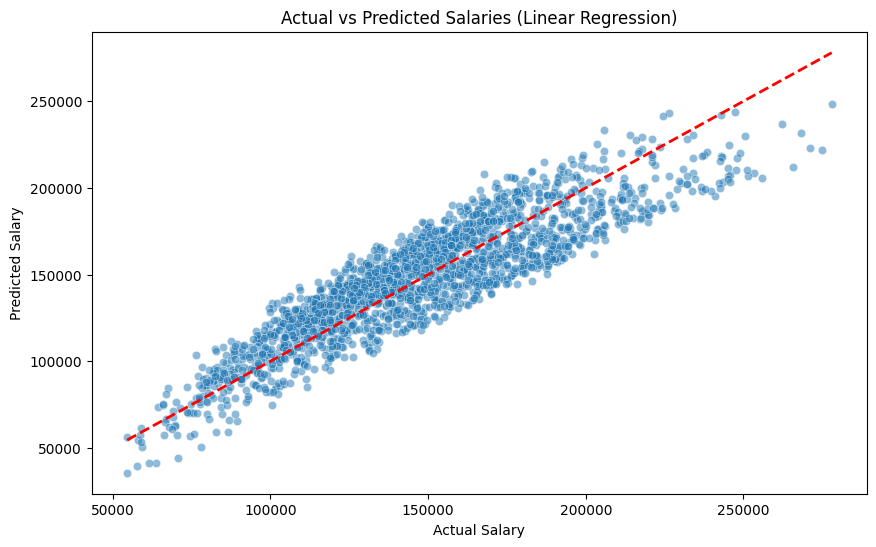

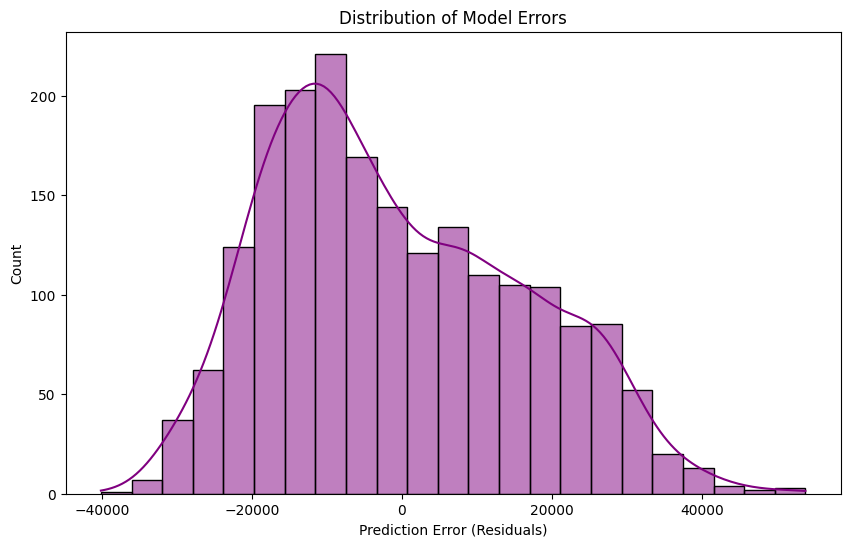

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Actual vs Predicted Values Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=lr_preds, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2)
plt.xlabel('Actual Salary')
plt.ylabel('Predicted Salary')
plt.title('Actual vs Predicted Salaries (Linear Regression)')
plt.savefig('actual_vs_predicted_lr.png') # Save the plot
plt.show()

# 2. Residual Plot (Error Analysis)
residuals = y_test - lr_preds
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True, color='purple')
plt.xlabel('Prediction Error (Residuals)')
plt.title('Distribution of Model Errors')
plt.savefig('residuals_distribution_lr.png') # Save the plot
plt.show()

In [13]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Calculate metrics for the Metric Table
mae = mean_absolute_error(y_test, lr_preds)
rmse = np.sqrt(mean_squared_error(y_test, lr_preds))
r2 = r2_score(y_test, lr_preds)

# Create the table
metrics_data = {
    'Metric': ['R-Squared (R2)', 'Mean Absolute Error (MAE)', 'Root Mean Squared Error (RMSE)'],
    'Value': [f"{r2:.4f}", f"${mae:,.2f}", f"${rmse:,.2f}"]
}
metrics_df = pd.DataFrame(metrics_data)
print("--- MODEL EVALUATION METRICS ---")
print(metrics_df)

--- MODEL EVALUATION METRICS ---
                           Metric       Value
0                  R-Squared (R2)      0.7996
1       Mean Absolute Error (MAE)  $14,264.97
2  Root Mean Squared Error (RMSE)  $16,879.94


--- 5-FOLD CROSS-VALIDATION RESULTS ---
Individual R2 Scores: [0.79507504 0.80727669 0.7975298  0.80236473 0.81133571]
Mean R2 Score: 0.8027
Standard Deviation of Scores: 0.0060


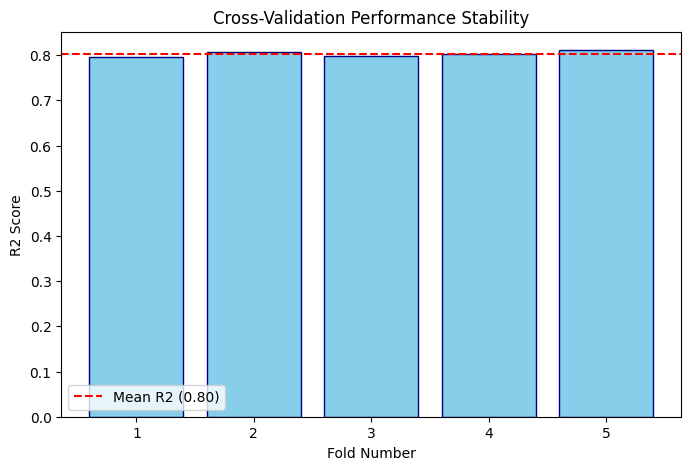

In [17]:
from sklearn.model_selection import cross_val_score

# We use 5-fold cross-validation (splitting data into 5 parts and testing 5 times)
# We use the Linear Regression model (lr_model)
cv_scores = cross_val_score(lr_model, X, y, cv=5, scoring='r2')

# Calculate mean and standard deviation of the scores
cv_mean = cv_scores.mean()
cv_std = cv_scores.std()

print("--- 5-FOLD CROSS-VALIDATION RESULTS ---")
print(f"Individual R2 Scores: {cv_scores}")
print(f"Mean R2 Score: {cv_mean:.4f}")
print(f"Standard Deviation of Scores: {cv_std:.4f}")

# Visualizing Cross-Validation results for your report
plt.figure(figsize=(8, 5))
plt.bar(range(1, 6), cv_scores, color='skyblue', edgecolor='navy')
plt.axhline(y=cv_mean, color='red', linestyle='--', label=f'Mean R2 ({cv_mean:.2f})')
plt.xlabel('Fold Number')
plt.ylabel('R2 Score')
plt.title('Cross-Validation Performance Stability')
plt.legend()
plt.savefig('cross_validation_r2_scores.png') # Save the plot
plt.show()

In [18]:
# --- STEP 7: MODEL DEPLOYMENT (SAVING) ---
import pickle

# Use 'lr_model' because it had the highest R2 score (0.80)
# and will create a very small file (under 100KB)
with open('best_salary_model.pkl', 'wb') as f:
    pickle.dump(lr_model, f)

# Save the columns as well
with open('model_columns.pkl', 'wb') as f:
    pickle.dump(list(X.columns), f)

print("Success! Your model is now tiny and ready for GitHub.")

Success! Your model is now tiny and ready for GitHub.
